# Recovering mirror misalignment

## We set different values for the misalignment:

In [1]:
# misalignments
SIGMA_V = 15.0
SIGMA_H = 25.0
MISALIGNMENT_SEED = 11

# scan values
HALF_ANGLE_DEG = 3.0
STEP_DIVISOR = 256
N_SAMPLES = 256

# yaml files
TELESCOPE_YAML = "../../../iactrace/configs/HESS/CT3.yaml"
CAMERA_YAML = "../../../iactrace/configs/HESS/HESS1U.yaml"

In [2]:
import astropy.units as u
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time
from iactrace import Camera, Telescope
from iactrace.analysis import effective_aperture
from iactrace.io import save_aperture_table

import nyx
from nyx import (
    Airglow,
    EffectiveApertureInstrument,
    Geometry,
    Observation,
    Optimizer,
    Scene,
    SingleScattering,
    Stars,
    dump_params,
    freeze_all,
    unfreeze,
)

nyx.configure()

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Telescope Creation

### Perfectly aligned telescope:

In [3]:
key1, key2, key3 = jax.random.split(jax.random.key(13), 3)

aligned = Telescope.from_yaml(TELESCOPE_YAML, n_samples=N_SAMPLES, key=key1)
camera = Camera.from_yaml(CAMERA_YAML)

aligned = (
    aligned.apply_roughness(0, 2.0)
    .apply_focal_error(0, 0.074, key2)
    .apply_displacement(0, 0.02, key3)
)

### Misaligned copy:

In [4]:
misaligned = aligned.apply_misalignment(
    0,
    sigma_h=SIGMA_H,
    sigma_v=SIGMA_V,
    key=jax.random.key(MISALIGNMENT_SEED),
)

## Two scans
We run scans over the telescope which is misaligned in IACTrace and the aligned one. We save the in-between result, since this is computationally expensive.

In [5]:
%%time
half_angle = np.deg2rad(HALF_ANGLE_DEG)
scan = dict(
    half_angle=half_angle,
    step=half_angle / STEP_DIVISOR,
    wavelengths=jnp.linspace(200, 700, 50),
    progress=True,
)

table_misaligned = effective_aperture(misaligned, camera, **scan)
save_aperture_table(
    table_misaligned,
    "CT1_misaligned.npz",
)

table_aligned = effective_aperture(aligned, camera, **scan)
save_aperture_table(table_aligned, "CT1_aligned.npz")

CPU times: user 12min 54s, sys: 4min 26s, total: 17min 21s
Wall time: 17min 19s


PosixPath('CT1_aligned.npz')

## Create both telescopes in nyx:

In [6]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 30) * u.nm,  # wavelength grid
    nside=16,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

truth_instrument = EffectiveApertureInstrument.from_iactrace_table(geo, "CT1_misaligned.npz")
model_instrument = EffectiveApertureInstrument.from_iactrace_table(
    geo, "CT1_aligned.npz", misalignment=15.0
)

step_arcsec = float(np.degrees(np.asarray(model_instrument.lattice.step)[0]) * 3600)
print(f"lattice step {step_arcsec:.1f} arcsec")
print(f"injected blur {2 * SIGMA_V / step_arcsec:.2f} x {2 * SIGMA_H / step_arcsec:.2f} nodes")

lattice step 42.2 arcsec
injected blur 0.71 x 1.19 nodes


## Creating a simple observation

Create a simplified observation using only airglow and stars

In [7]:
location = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)
times = Time("2021-06-11T21:00:00", scale="utc") + jnp.linspace(0, 30, 120) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")
obs = Observation(location, times, target, geo)

atmosphere = SingleScattering.from_hg_ozone(geo)
sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
}

truth = Scene.build(truth_instrument, atmosphere, sources, obs)
model = Scene.build(model_instrument, atmosphere, sources, obs)

In [20]:
rel_error = 0.03

rng = np.random.default_rng(42)
rates = truth.render()["instrument"]
data = jnp.asarray(np.asarray(rates) * rng.lognormal(0.0, rel_error, size=rates.shape))

## Fitting

In [23]:
%%time
start = unfreeze(
    freeze_all(model),
    "instruments.instrument.misalignment_lon",
    "instruments.instrument.misalignment_lat",
    "instruments.instrument.efficiency",
)


def residuals(scene):
    return (jnp.log(scene.render()["instrument"]) - jnp.log(data)) / rel_error


opt = Optimizer(residuals, optx.LBFGS(rtol=1e-7, atol=1e-7))
fitted, sol = opt.run(start, max_steps=512)
errors = opt.errors(fitted)

print(opt.summary(fitted, sol))

FitSummary(
  chi2         119497
  d.o.f.       115197 = 115200 data - 3 free
  chi2/d.o.f.  1.03733
  solver       converged, 60 steps
)
CPU times: user 9.98 s, sys: 568 ms, total: 10.5 s
Wall time: 6.66 s


## Recovery from direct fit

In [24]:
AXES = ("misalignment_lon", "misalignment_lat")
recovered = np.array([float(getattr(fitted.instrument, a).value) for a in AXES])
sigma = np.array([float(getattr(errors.instrument, a).value) for a in AXES])
injected = np.array([SIGMA_V, SIGMA_H])

for i, axis in enumerate(AXES):
    print(
        f"  {axis:17s} = {recovered[i]:6.2f} +- {sigma[i]:4.2f} arcsec"
        f"   injected {injected[i]:5.1f}   ({recovered[i] - injected[i]:+.2f})"
    )

  misalignment_lon  =  16.88 +- 0.28 arcsec   injected  15.0   (+1.88)
  misalignment_lat  =  24.71 +- 0.19 arcsec   injected  25.0   (-0.29)


## Profile scan over misalignment

In [19]:
best = dump_params(fitted)
sigma = dump_params(errors)

In [14]:
%%time
mis_lon = "instruments.instrument.misalignment_lon"
mis_lat = "instruments.instrument.misalignment_lat"


def axis(name, n, k=10.0):
    lo = max(float(best[name]) - k * float(sigma[name]), 0.0)
    hi = float(best[name]) + k * float(sigma[name])
    return np.linspace(lo, hi, n)


grid = opt.profile(
    fitted,
    {mis_lon: axis(mis_lon, 11), mis_lat: axis(mis_lat, 10)},
    max_steps=512,
    callback=lambda *_: print(".", end="", flush=True),
)
print()
print(grid)

....................................................................................................................................................................................................................................................................................................................................................................................................................................
ProfileGrid(instruments.instrument.misalignment_lon in [14.02, 19.66] (21), instruments.instrument.misalignment_lat in [23.02, 26.85] (20))
  best chi2 117918 at instruments.instrument.misalignment_lon=15.149, instruments.instrument.misalignment_lat=25.2376
  1/2/3 sigma at delta chi2 (2.3, 6.18, 11.83)
CPU times: user 8min 35s, sys: 32.8 s, total: 9min 8s
Wall time: 8min 36s


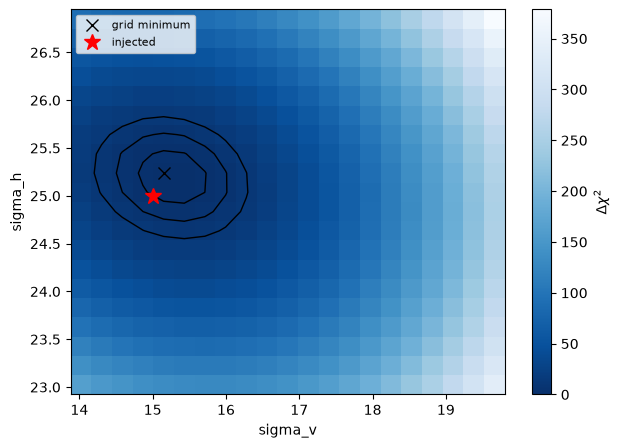

In [15]:
x, y = grid.axes
z = grid.delta_chi2.T

fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(x, y, z, shading="nearest", cmap="Blues_r")
ax.contour(x, y, z, levels=grid.levels, colors="k", linewidths=1)
ax.plot(*grid.best.values(), "kx", ms=9, label="grid minimum")
ax.plot(SIGMA_V, SIGMA_H, "r*", ms=12, label="injected")

ax.set_xlabel("sigma_v")
ax.set_ylabel("sigma_h")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(mesh, label=r"$\Delta \chi^2$")